In [15]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from tools import *

In [16]:
df = pd.read_csv('/Users/kellyhui/Downloads/RBG_data/KH_RBG_103025.csv')
df = clean_and_transpose(df, 31, 129)
df1 = df.copy()

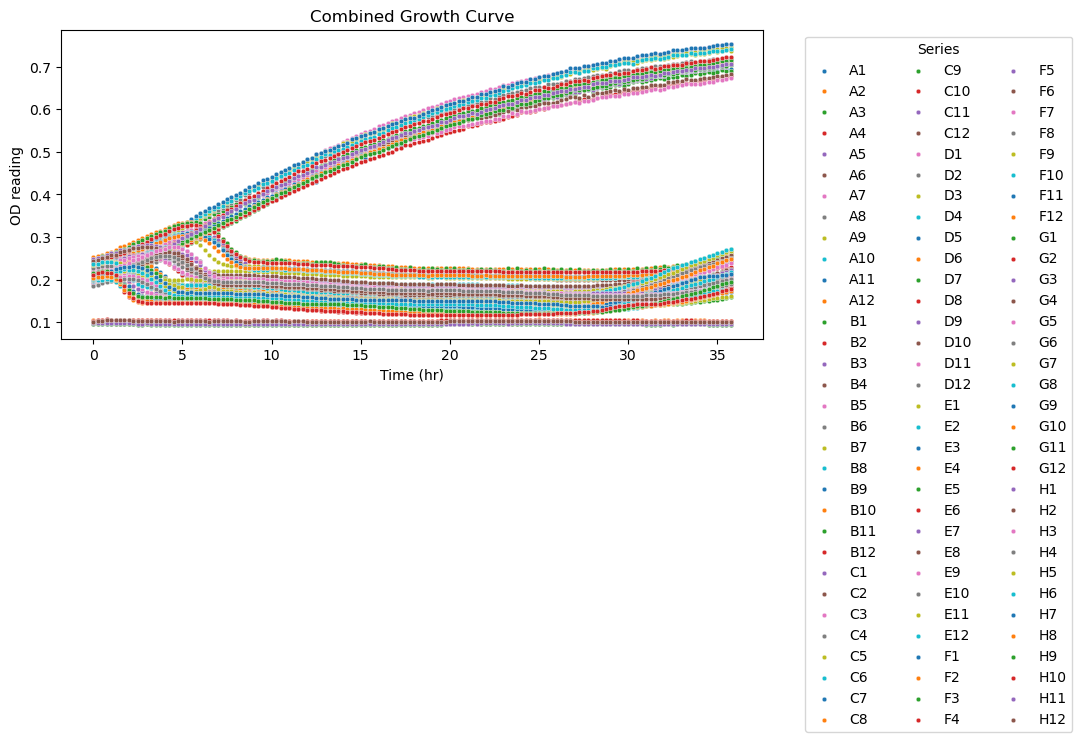

In [7]:
plot_timeseries(df, 'Combined Growth Curve')

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


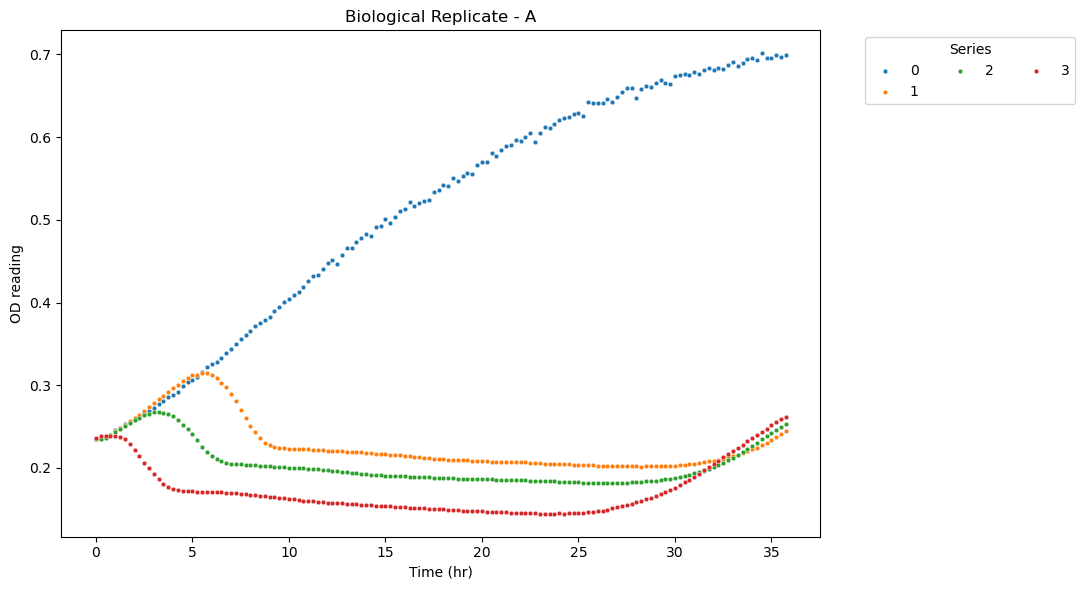

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


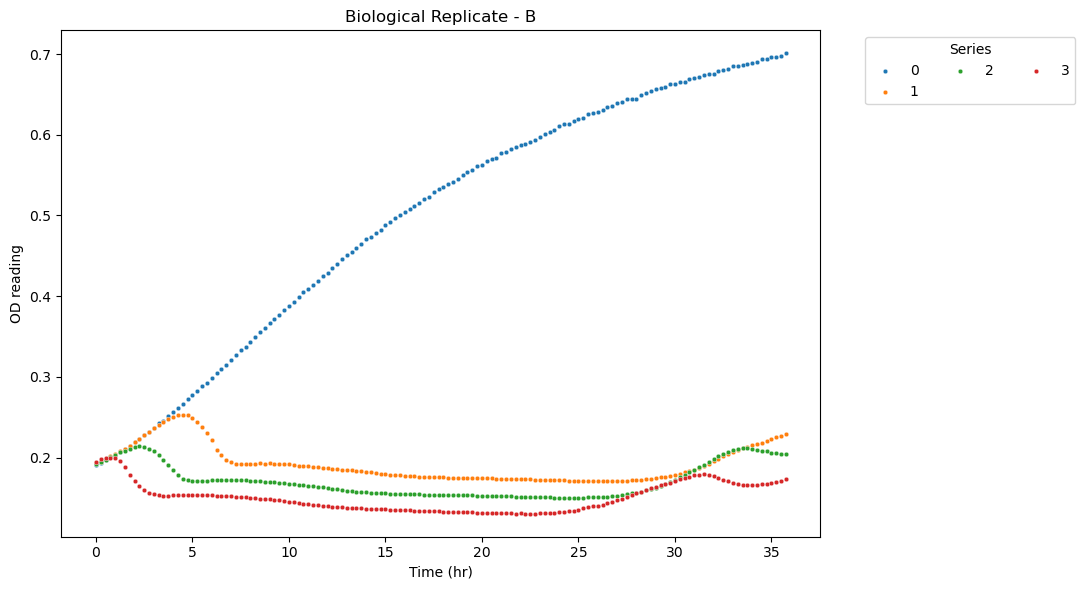

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


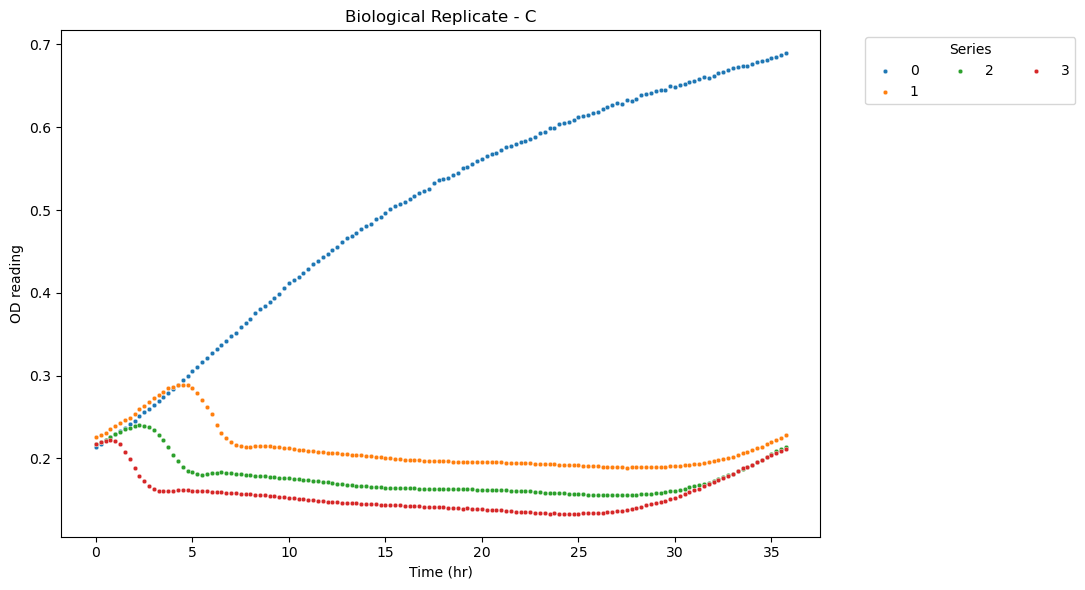

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


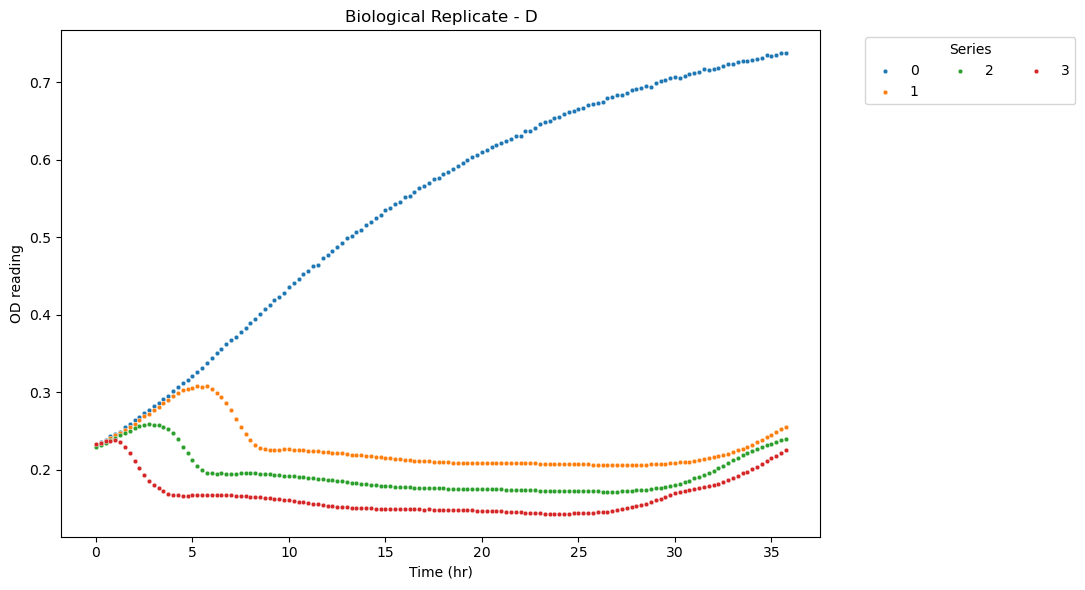

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


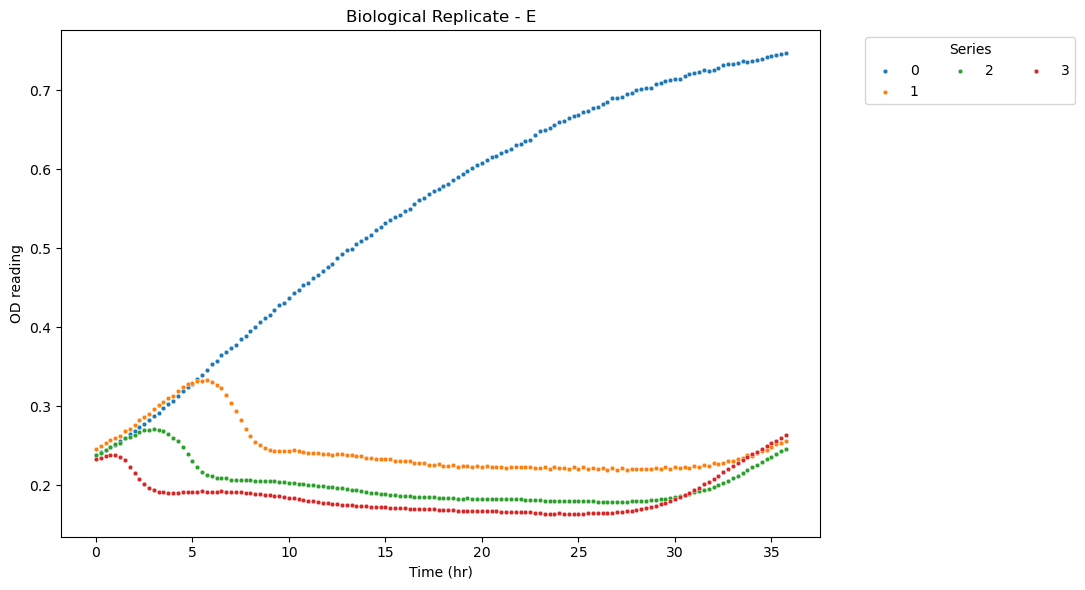

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


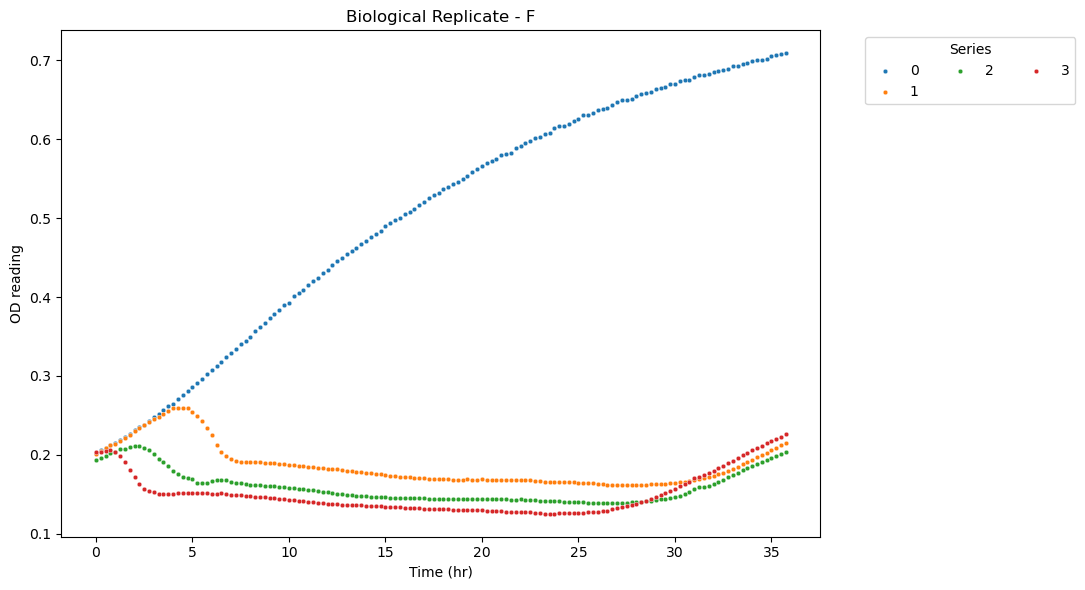

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


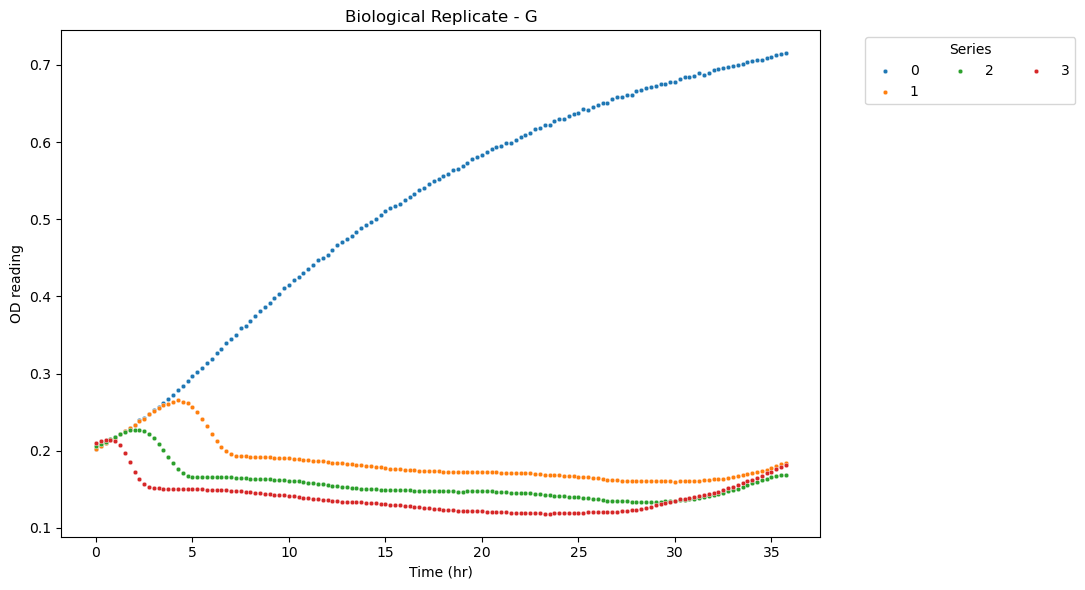

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis=1).mean()


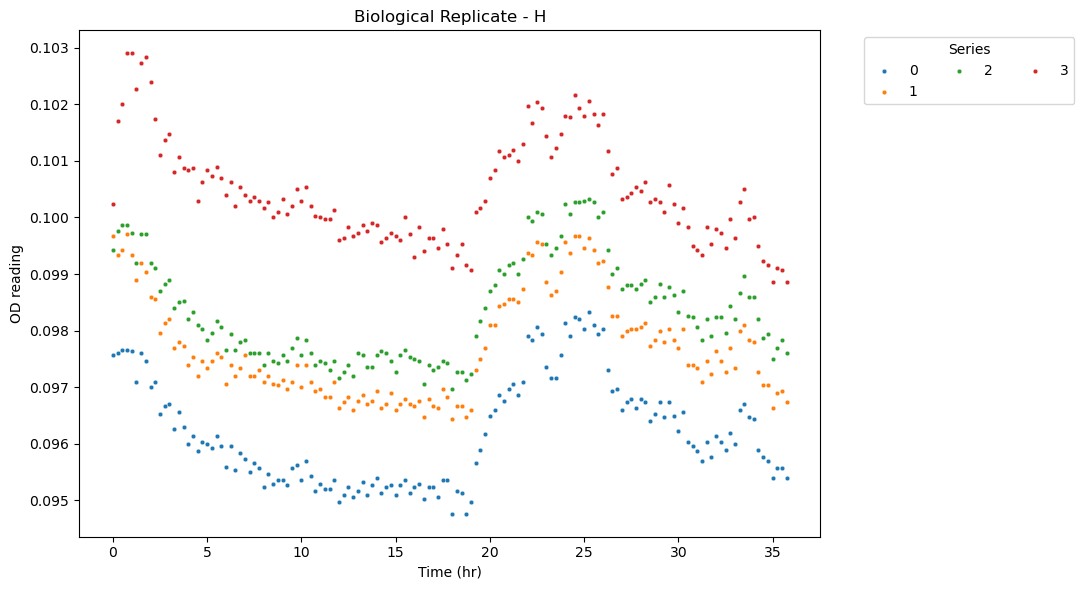

In [8]:
plot_biol_rep(df, num_bio_rep=8, col_num=3)

In [20]:
def plot_dose_response(df, pfu, num_tech_reps=3):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import string
    from scipy.stats import linregress

    df.index = np.round(df.index).astype(int)

    df_hourly = df.loc[df.index.isin(range(0, 16))]
    df_hourly = df_hourly.groupby(df_hourly.index).first()

    x_vals = np.array([0 if p == 0 else np.log10(p) for p in pfu])

    bio_reps = list(string.ascii_uppercase)[:df_hourly.shape[1] // num_tech_reps]

    for hour, row in df_hourly.iterrows():

        all_reps = []

        plt.figure(figsize=(8, 6))

        # ---- COLLECT DATA ----
        for letter in bio_reps:

            table = df_hourly.filter(regex=rf'^{letter}')
            if table.empty:
                continue

            table_avg = pd.DataFrame({
                i: table.iloc[:, i*num_tech_reps:(i+1)*num_tech_reps].mean(axis=1)
                for i in range(len(pfu))
            })

            y_vals = table_avg.loc[hour].values
            all_reps.append(y_vals)

            # plot biological replicates (optional)
            plt.plot(x_vals, y_vals, marker='o', alpha=0.7)

        # ---- ANALYSIS (AFTER LOOP) ----
        all_reps = np.array(all_reps)
        mean_vals = np.mean(all_reps, axis=0)

        slope, intercept, r_value, p_value, _ = linregress(x_vals, mean_vals)
        r2 = r_value**2

        y_fit = slope * x_vals + intercept

        # mean points
        #plt.plot(x_vals, mean_vals, 'o', color='black')

        # fitted line
        plt.plot(
            x_vals,
            y_fit,
            linestyle='--', linewidth=2, color='black'
        )

        plt.xlabel('log10(PFU)')
        plt.ylabel('OD')
        plt.title('99TK Ancestor 'f'(R²={r2:.2f}, p={p_value:.2g})')
        plt.legend()
        plt.grid(False)

        plt.show()

In [18]:
pfu_values = [0, 1e3, 1e5, 1e7]

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


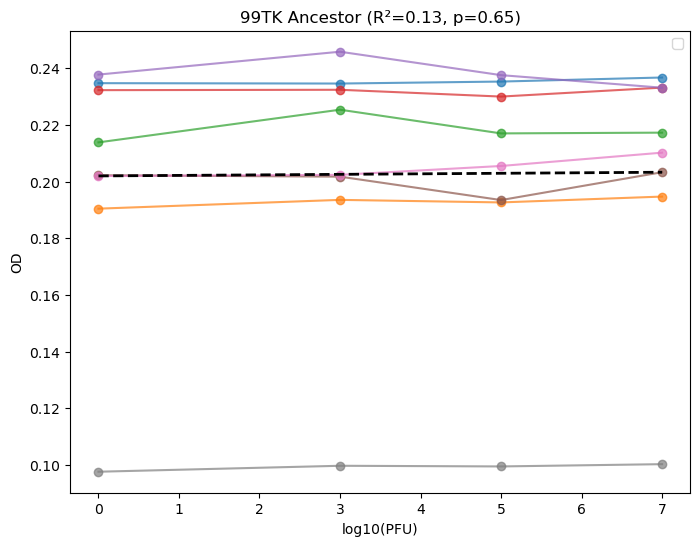

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


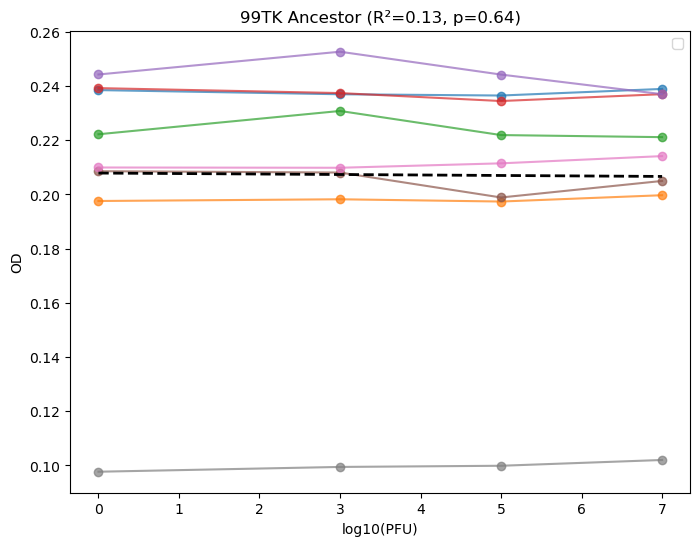

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


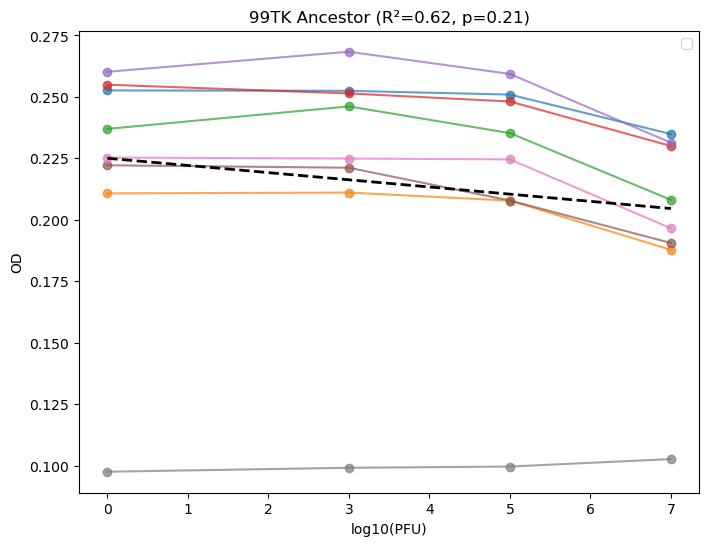

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


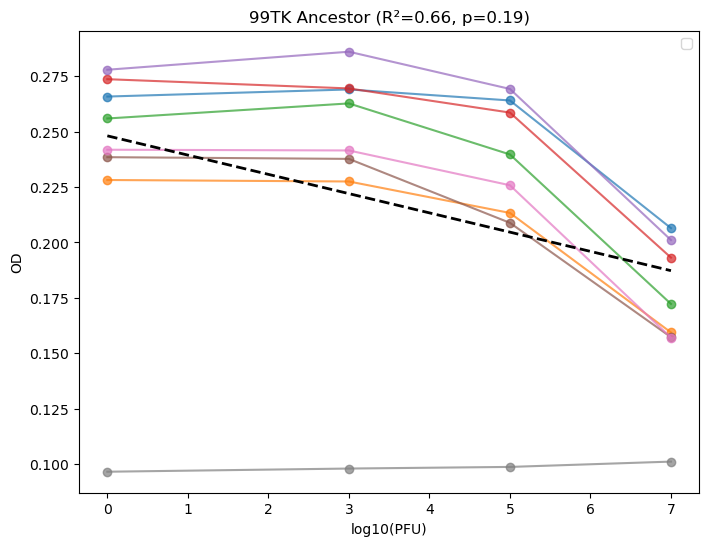

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


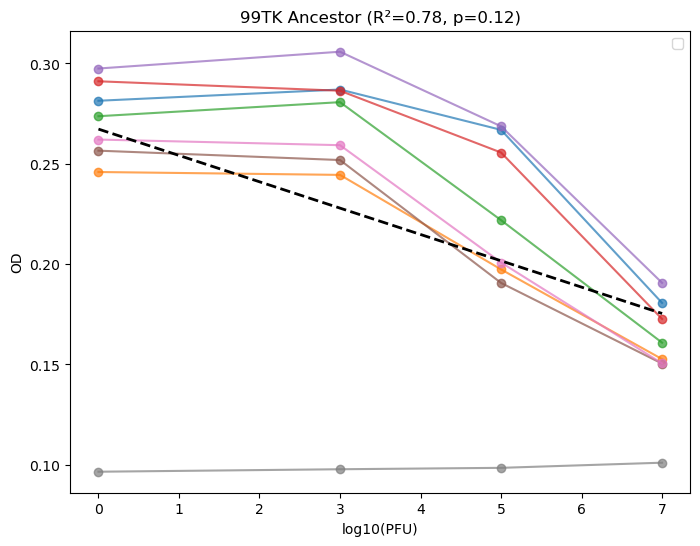

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


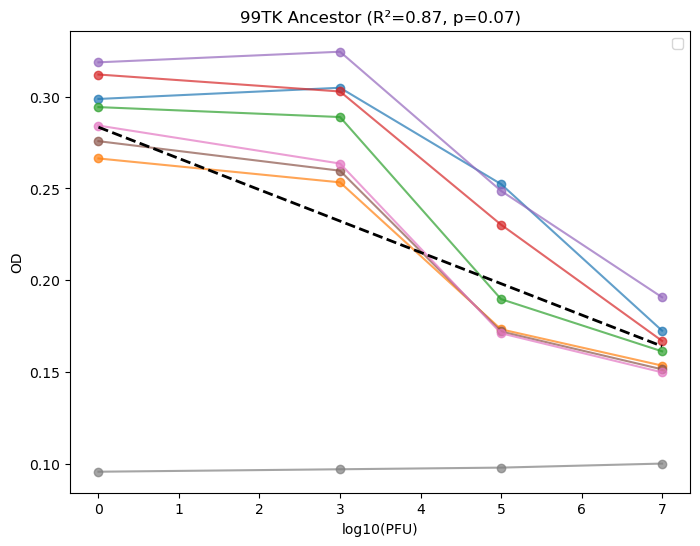

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


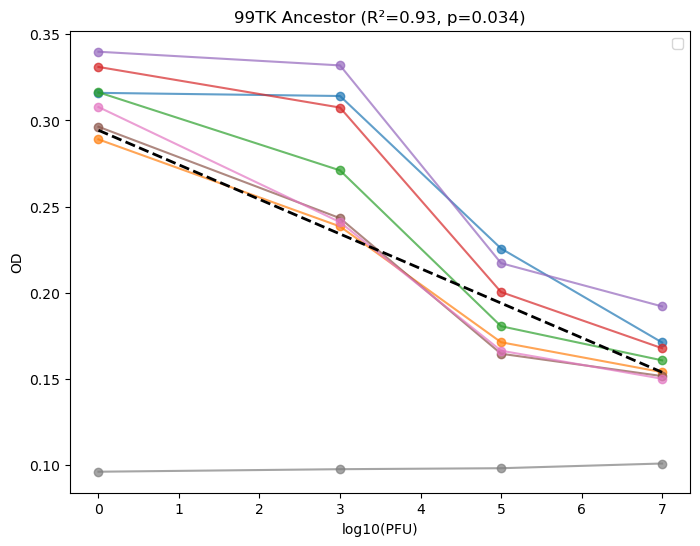

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


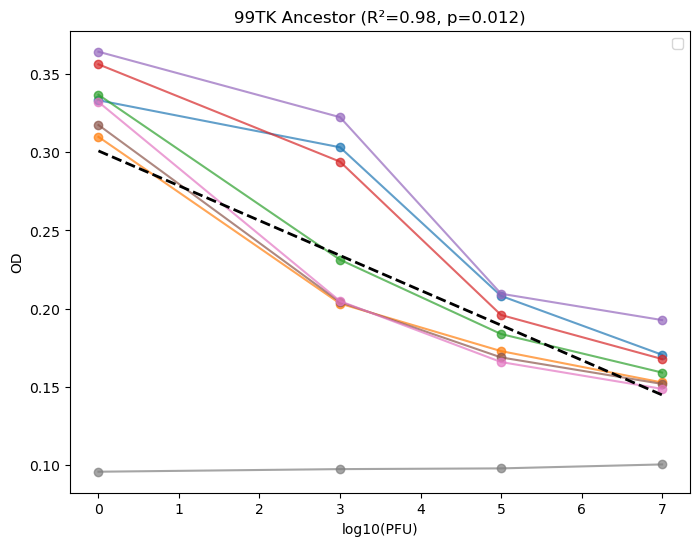

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


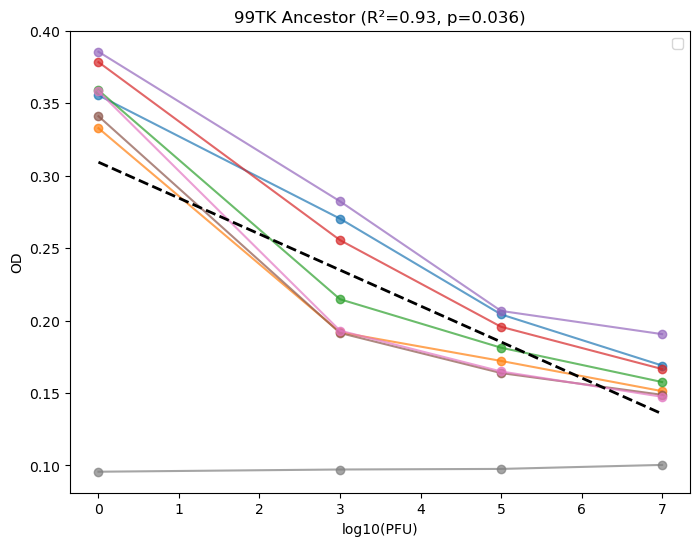

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


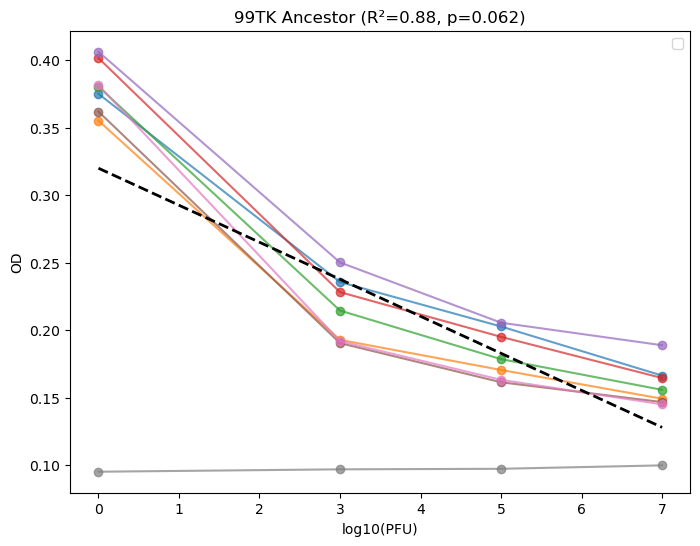

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


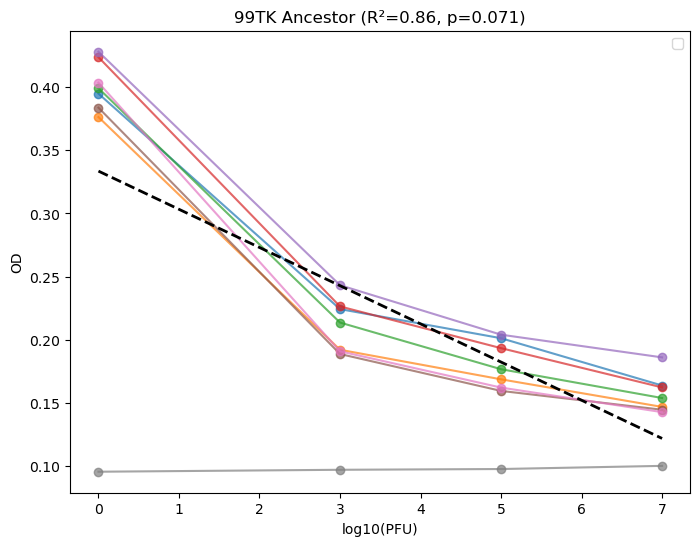

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


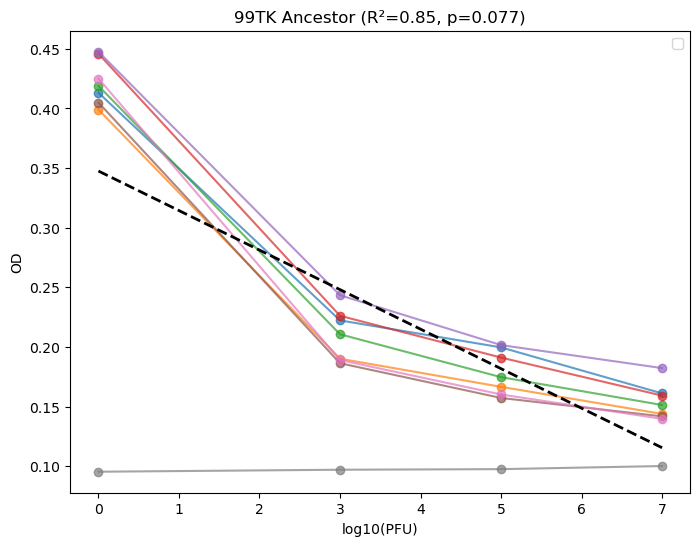

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


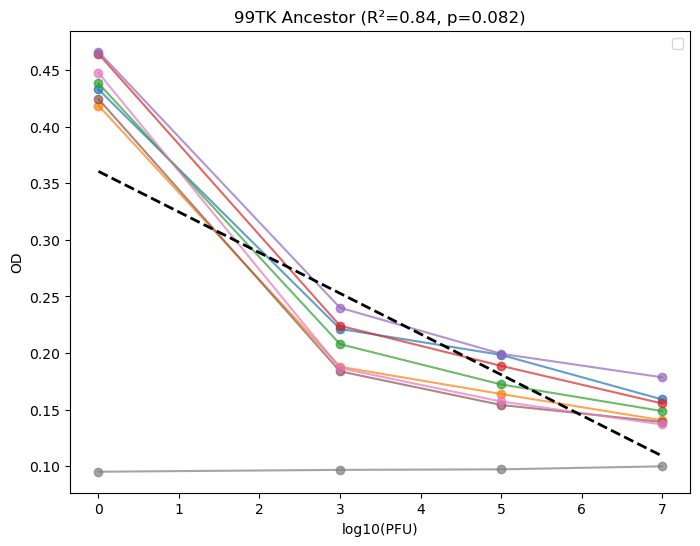

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


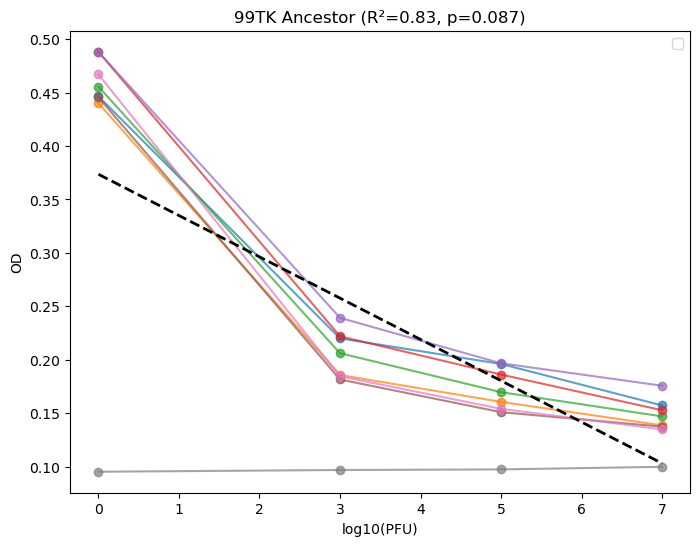

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


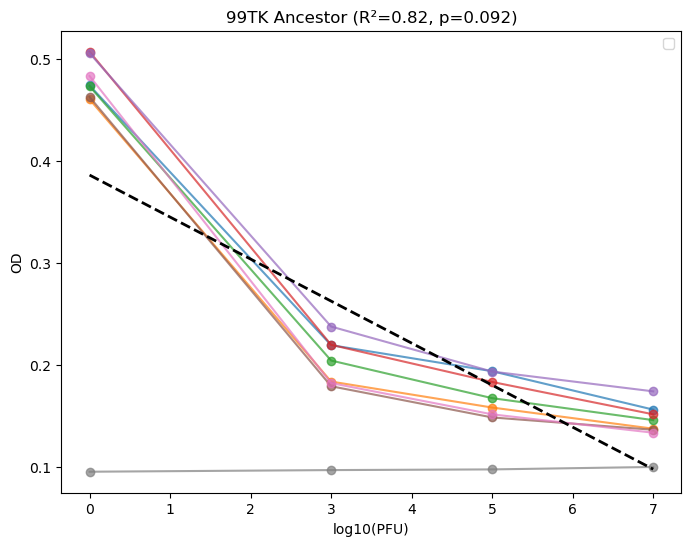

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_44177/1471775673.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


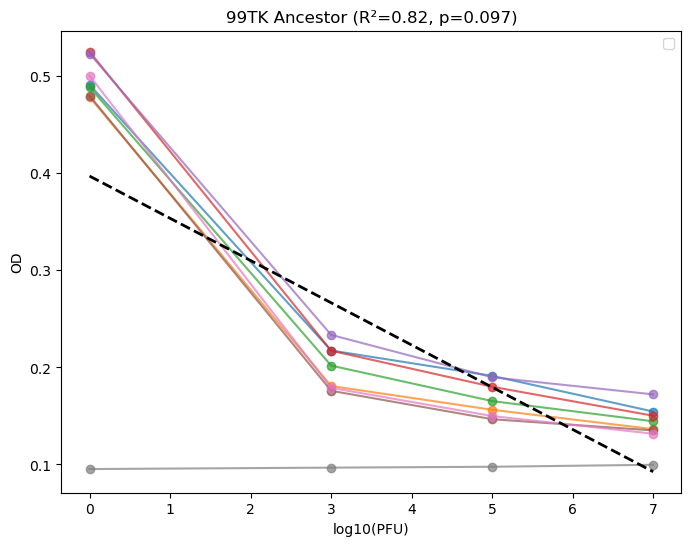

In [21]:
plot_dose_response(df, pfu_values)